<a href="https://colab.research.google.com/github/Duvandoe/Taller1_corte2_IA/blob/main/Taller2_corte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

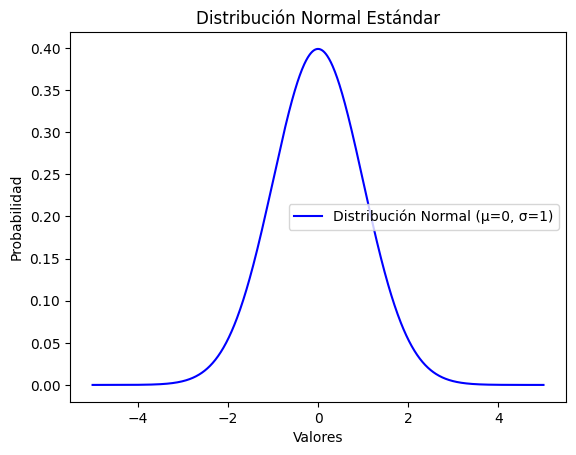

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros de la distribución
mu = 0       # media
sigma = 1    # desviación estándar

# Generar valores
x = np.linspace(-5, 5, 1000)
y = norm.pdf(x, mu, sigma)

# Gráfica
plt.plot(x, y, color='blue', label='Distribución Normal (μ=0, σ=1)')
plt.title('Distribución Normal Estándar')
plt.xlabel('Valores')
plt.ylabel('Probabilidad')
plt.legend()
plt.show()

Media muestral: 48.12
Intervalo de confianza del 95%: (44.76, 51.48)


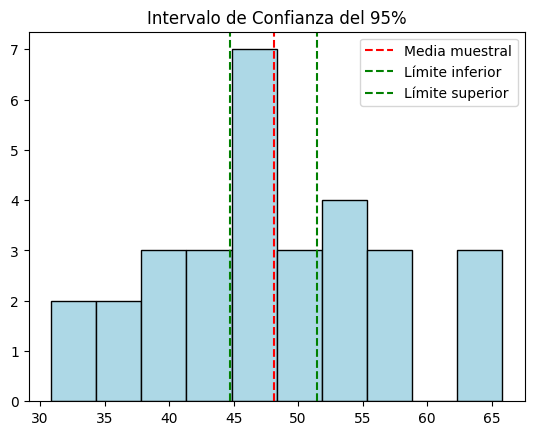

In [ ]:
# INTERVALOS DE CONFIANZA
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Simular una muestra
np.random.seed(42)
muestra = np.random.normal(loc=50, scale=10, size=30)  # media=50, desviación=10, n=30

# Calcular estadísticos básicos
media_muestra = np.mean(muestra)
desv_muestra = np.std(muestra, ddof=1)  # ddof=1 para obtener la desviación muestral
n = len(muestra)

# Nivel de confianza (95%)
confianza = 0.95
t_critico = stats.t.ppf((1 + confianza) / 2, df=n-1)

# Margen de error
margen = t_critico * (desv_muestra / np.sqrt(n))

# Intervalo de confianza
ic_inf = media_muestra - margen
ic_sup = media_muestra + margen

# Mostrar resultados
print(f"Media muestral: {media_muestra:.2f}")
print(f"Intervalo de confianza del 95%: ({ic_inf:.2f}, {ic_sup:.2f})")

# Visualización
plt.hist(muestra, bins=10, color='lightblue', edgecolor='black')
plt.axvline(media_muestra, color='red', linestyle='--', label='Media muestral')
plt.axvline(ic_inf, color='green', linestyle='--', label='Límite inferior')
plt.axvline(ic_sup, color='green', linestyle='--', label='Límite superior')
plt.title('Intervalo de Confianza del 95%')
plt.legend()
plt.show()

Pruebas t y ANOVA

Las pruebas t y el ANOVA se utilizan para comparar medias entre grupos y determinar si las diferencias observadas son estadísticamente significativas o solo producto del azar.

1. Prueba t de una muestra

Sirve para comparar la media de una muestra con un valor conocido (por ejemplo, una media teórica o estándar).

Ejemplo en Python:

Supongamos que una fábrica dice que sus tornillos tienen una longitud media de 50 mm, pero tomamos una muestra para comprobarlo.

In [ ]:
# PRUEBA T MUESTRA
import numpy as np
from scipy import stats

# Muestra simulada
np.random.seed(1)
muestra = np.random.normal(loc=49.5, scale=1, size=30)

# Hipótesis:
# H0: μ = 50  (la media es igual a 50)
# H1: μ ≠ 50  (la media es diferente de 50)

t_stat, p_valor = stats.ttest_1samp(muestra, 50)

print(f"Estadístico t = {t_stat:.3f}")
print(f"Valor p = {p_valor:.4f}")

if p_valor < 0.05:
    print("Rechazamos H0: la media es significativamente diferente de 50.")
else:
    print("No se rechaza H0: la media no difiere significativamente de 50.")

Estadístico t = -2.988
Valor p = 0.0057
Rechazamos H0: la media es significativamente diferente de 50.


Explicación:

Se usa ttest_1samp para comparar la media de la muestra con un valor de referencia.

Si el p-valor < 0.05, hay evidencia suficiente para rechazar la hipótesis nula (la media no es 50).

Si p > 0.05, la diferencia podría deberse al azar.

-----

2. Prueba t para muestras relacionadas (pareadas)

Se usa cuando se comparan dos mediciones del mismo grupo, por ejemplo, antes y después de un tratamiento.

In [ ]:
# PRUEBA T PARA MUESTRAS RELACIONADAS
import numpy as np
import scipy.stats as stats

# Pesos antes y después de una dieta
np.random.seed(88)  # para reproducibilidad
antes = np.random.normal(80, 4, 20)
despues = antes - np.random.normal(2, 1, 20)  # pierden peso en promedio

# Hipótesis:
# H0: No hay cambio en el peso
# H1: Sí hay cambio

t_stat, p_valor = stats.ttest_rel(antes, despues)

print(f"Estadístico t = {t_stat:.3f}")
print(f"Valor p = {p_valor:.4f}")

if p_valor < 0.05:
    print("Rechazamos H0: hubo un cambio significativo en el peso.")
else:
    print("No se rechaza H0: no hubo cambio significativo.")

Estadístico t = 8.761
Valor p = 0.0000
Rechazamos H0: hubo un cambio significativo en el peso.


Explicación:

ttest_rel() se usa para comparar mediciones dependientes (mismas personas antes y después).

Es más sensible que la prueba t independiente, porque elimina la variabilidad individual.

-----
3. ANOVA (Análisis de Varianza)

El ANOVA se usa cuando queremos comparar las medias de más de dos grupos.

Ejemplo: comparar el rendimiento de tres métodos de enseñanza distintos.

In [ ]:
# ANOVA de una vía - Comparar tres métodos de estudio
import numpy as np
from scipy import stats

# Tres grupos de estudiantes con distintos métodos de enseñanza
np.random.seed(3)
metodo1 = np.random.normal(75, 5, 30)
metodo2 = np.random.normal(80, 5, 30)
metodo3 = np.random.normal(78, 5, 30)

# Hipótesis:
# H0: Todas las medias son iguales
# H1: Al menos una media es diferente

f_stat, p_valor = stats.f_oneway(metodo1, metodo2, metodo3)

print(f"Estadístico F = {f_stat:.3f}")
print(f"Valor p = {p_valor:.4f}")

if p_valor < 0.05:
    print("Rechazamos H0: hay diferencia significativa entre los métodos.")
else:
    print("Mo se rechaza H0: no hay diferencias significativas entre los métodos.")

Estadístico F = 5.713
Valor p = 0.0047
Rechazamos H0: hay diferencia significativa entre los métodos.


Explicación:

f_oneway() realiza un ANOVA de una vía.

Si p < 0.05, al menos un grupo es distinto.

No indica cuál grupo difiere; para eso se usan pruebas post-hoc (como Tukey).

-----
4. Prueba t de dos muestras independientes

Sirve para comparar las medias de dos grupos distintos.
Por ejemplo, comparar el peso promedio de hombres y mujeres.

In [ ]:
# PRUEBA T PARA MUESTRAS INDEPENDIENTES
import numpy as np
from scipy import stats

# Generar datos simulados
np.random.seed(2)
grupo_A = np.random.normal(70, 5, 30)  # grupo A
grupo_B = np.random.normal(73, 5, 30)  # grupo B

# Hipótesis:
# H0: μA = μB  (no hay diferencia entre medias)
# H1: μA ≠ μB  (sí hay diferencia entre medias)

t_stat, p_valor = stats.ttest_ind(grupo_A, grupo_B)

print(f"Estadístico t = {t_stat:.3f}")
print(f"Valor p = {p_valor:.4f}")

if p_valor < 0.05:
    print("Rechazamos H0: hay diferencia significativa entre los grupos.")
else:
    print("No se rechaza H0: no hay diferencia significativa entre los grupos.")

Estadístico t = -3.972
Valor p = 0.0002
Rechazamos H0: hay diferencia significativa entre los grupos.


Explicación:

ttest_ind() compara medias de dos grupos independientes.

Asume que las varianzas son iguales (se puede usar equal_var=False si no lo son).

Si el p-valor < 0.05 → la diferencia entre grupos es significativa.

Coeficiente de correlación r = 0.945
Valor p = 0.0000


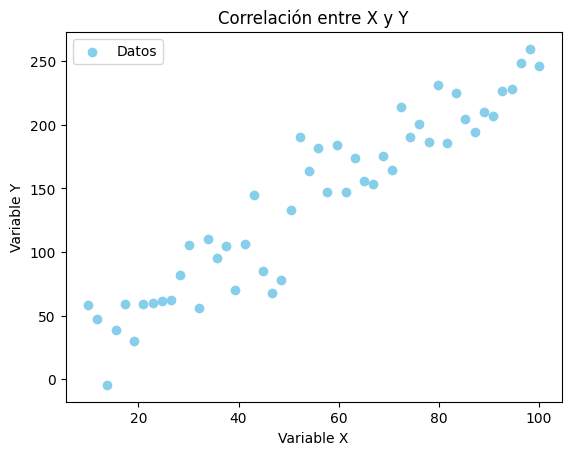

In [ ]:
#PARTE 3 — Correlación y Regresión Lineal Simple
#CORRELACIÓN
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Simular datos
np.random.seed(10)
x = np.linspace(10, 100, 50)
y = 2.5 * x + np.random.normal(0, 25, 50)  # relación lineal con ruido

# Calcular correlación de Pearson
r, p_valor = stats.pearsonr(x, y)

print(f"Coeficiente de correlación r = {r:.3f}")
print(f"Valor p = {p_valor:.4f}")

# Visualización
plt.scatter(x, y, color='skyblue', label='Datos')
plt.title('Correlación entre X y Y')
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.legend()
plt.show()

Ecuación de la recta: y = 2.44x + 5.68


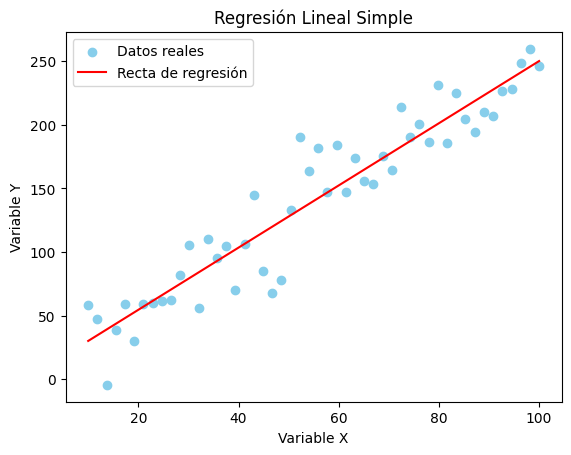

In [ ]:
#Regresión Lineal Simple
from sklearn.linear_model import LinearRegression

# Reformatear los datos (scikit-learn requiere matrices)
X = x.reshape(-1, 1)
Y = y

# Crear modelo
modelo = LinearRegression()
modelo.fit(X, Y)

# Obtener pendiente y ordenada
pendiente = modelo.coef_[0]
intercepto = modelo.intercept_

# Predicciones
y_pred = modelo.predict(X)

print(f"Ecuación de la recta: y = {pendiente:.2f}x + {intercepto:.2f}")

# Gráfico
plt.scatter(X, Y, color='skyblue', label='Datos reales')
plt.plot(X, y_pred, color='red', label='Recta de regresión')
plt.title('Regresión Lineal Simple')
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.legend()
plt.show()

In [ ]:
#Medición del ajuste (R²)
r2 = modelo.score(X, Y)
print(f"Coeficiente de determinación R² = {r2:.3f}")

#Si R² = 0.90 → el 90% de la variación de Y se explica por X.

#Si R² es bajo (< 0.3), la relación entre X y Y es débil.

Coeficiente de determinación R² = 0.893


In [ ]:
#PARTE 4 — Pruebas de Hipótesis y Tipos de Error
import numpy as np
from scipy import stats

# Simulamos una muestra de bombillos
np.random.seed(42)
muestra = np.random.normal(loc=980, scale=40, size=30)  # media < 1000

# Hipótesis:
# H0: μ = 1000
# H1: μ ≠ 1000

t_stat, p_valor = stats.ttest_1samp(muestra, 1000)

print(f"Estadístico t = {t_stat:.3f}")
print(f"Valor p = {p_valor:.4f}")

if p_valor < 0.05:
    print("❌ Rechazamos H₀: la vida útil difiere significativamente de 1000 horas.")
else:
    print("✅ No se rechaza H₀: no hay evidencia de que difiera de 1000 horas.")

Estadístico t = -4.188
Valor p = 0.0002
❌ Rechazamos H₀: la vida útil difiere significativamente de 1000 horas.


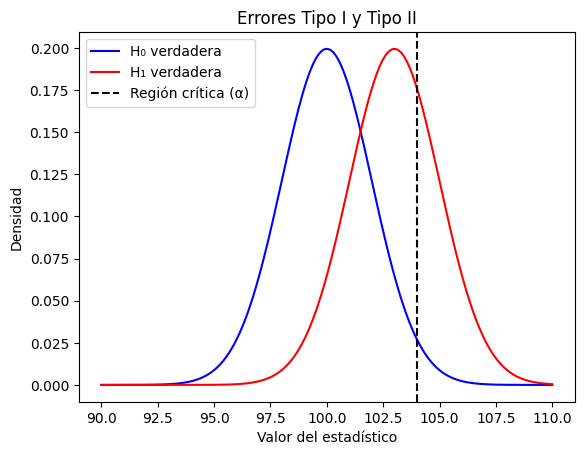

In [ ]:
#Tipos de error
#Visualización conceptual
import matplotlib.pyplot as plt
import numpy as np

# Distribuciones hipotéticas
x = np.linspace(90, 110, 500)
dist_H0 = stats.norm.pdf(x, 100, 2)
dist_H1 = stats.norm.pdf(x, 103, 2)

plt.plot(x, dist_H0, label='H₀ verdadera', color='blue')
plt.plot(x, dist_H1, label='H₁ verdadera', color='red')
plt.axvline(104, color='black', linestyle='--', label='Región crítica (α)')
plt.title('Errores Tipo I y Tipo II')
plt.xlabel('Valor del estadístico')
plt.ylabel('Densidad')
plt.legend()
plt.show()

In [ ]:
#Nivel de significancia y poder estadístico
np.random.seed(1)
grupo_control = np.random.normal(50, 5, 30)
grupo_tratamiento = np.random.normal(53, 5, 30)

# Hipótesis:
# H0: μ_control = μ_tratamiento
# H1: μ_control ≠ μ_tratamiento

t_stat, p_valor = stats.ttest_ind(grupo_control, grupo_tratamiento)
print(f"t = {t_stat:.3f}, p = {p_valor:.4f}")

if p_valor < 0.05:
    print("❌ Rechazamos H₀: el tratamiento produce un cambio significativo.")
else:
    print("✅ No se rechaza H₀: no hay evidencia suficiente de un cambio.")

t = -3.035, p = 0.0036
❌ Rechazamos H₀: el tratamiento produce un cambio significativo.


# Correlación y Regresión Lineal Simple

- 1. Correlación:
  - La correlación mide el grado en que dos variables están relacionadas.
Se expresa con el coeficiente de correlación de Pearson (r), que va de:

    +1 → relación positiva perfecta (si una sube, la otra sube)

    0 → sin relación

    −1 → relación negativa perfecta (si una sube, la otra baja)



```
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Simular datos
np.random.seed(10)
x = np.linspace(10, 100, 50)
y = 2.5 * x + np.random.normal(0, 25, 50)  # relación lineal con ruido

# Calcular correlación de Pearson
r, p_valor = stats.pearsonr(x, y)

print(f"Coeficiente de correlación r = {r:.3f}")
print(f"Valor p = {p_valor:.4f}")

# Visualización
plt.scatter(x, y, color='skyblue', label='Datos')
plt.title('Correlación entre X y Y')
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.legend()
plt.show()

```
stats.pearsonr() devuelve el coeficiente de correlación y el valor p.

Si r está cerca de 1 o -1, hay una relación fuerte (positiva o negativa).

El p-valor indica si esa correlación es significativa estadísticamente.

Ejemplo:

r = 0.92, p < 0.05 → hay una fuerte correlación positiva entre X y Y.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Simular datos
np.random.seed(10)
x = np.linspace(10, 100, 50)
y = 2.5 * x + np.random.normal(0, 25, 50)  # relación lineal con ruido

# Calcular correlación de Pearson
r, p_valor = stats.pearsonr(x, y)

print(f"Coeficiente de correlación r = {r:.3f}")
print(f"Valor p = {p_valor:.4f}")

# Visualización
plt.scatter(x, y, color='skyblue', label='Datos')
plt.title('Correlación entre X y Y')
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.legend()
plt.show()

- 2. Regresión Lineal Simple
    - La regresión lineal se usa para modelar la relación entre dos variables:
una dependiente (Y) y una independiente (X).
Permite predecir valores de Y a partir de X.



```
from sklearn.linear_model import LinearRegression

# Reformatear los datos (scikit-learn requiere matrices)
X = x.reshape(-1, 1)
Y = y

# Crear modelo
modelo = LinearRegression()
modelo.fit(X, Y)

# Obtener pendiente y ordenada
pendiente = modelo.coef_[0]
intercepto = modelo.intercept_

# Predicciones
y_pred = modelo.predict(X)

print(f"Ecuación de la recta: y = {pendiente:.2f}x + {intercepto:.2f}")

# Gráfico
plt.scatter(X, Y, color='skyblue', label='Datos reales')
plt.plot(X, y_pred, color='red', label='Recta de regresión')
plt.title('Regresión Lineal Simple')
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.legend()
plt.show()

```
La ecuación ajustada tiene la forma:

𝑦 = 𝑎𝑥 + 𝑏

donde:

a = pendiente (cuánto cambia Y por cada unidad de X)

b = intercepto (valor de Y cuando X = 0)

modelo.fit() ajusta la línea que mejor se adapta a los datos.

modelo.predict() genera los valores predichos.

- Interpretación visual

La recta roja representa la predicción del modelo, mientras que los puntos azules son los valores reales.
Si los puntos están cerca de la recta, el modelo tiene buena precisión.

In [ ]:
from sklearn.linear_model import LinearRegression

# Reformatear los datos (scikit-learn requiere matrices)
X = x.reshape(-1, 1)
Y = y

# Crear modelo
modelo = LinearRegression()
modelo.fit(X, Y)

# Obtener pendiente y ordenada
pendiente = modelo.coef_[0]
intercepto = modelo.intercept_

# Predicciones
y_pred = modelo.predict(X)

print(f"Ecuación de la recta: y = {pendiente:.2f}x + {intercepto:.2f}")

# Gráfico
plt.scatter(X, Y, color='skyblue', label='Datos reales')
plt.plot(X, y_pred, color='red', label='Recta de regresión')
plt.title('Regresión Lineal Simple')
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.legend()
plt.show()

- Medición del ajuste (R²)
    - El coeficiente de determinación (R²) mide cuánto del comportamiento de Y se explica por X.
    

```
r2 = modelo.score(X, Y)
print(f"Coeficiente de determinación R² = {r2:.3f}")
```
Si R² = 0.90 → el 90% de la variación de Y se explica por X.

Si R² es bajo (< 0.3), la relación entre X y Y es débil.